In [1]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
A = np.array([[2, 0], [-1, 1], [0,2]])
b = np.array([2, 0, -2]).T
x = LA.inv(A.T.dot(A)).dot(A.T).dot(b)
rss = LA.norm(b - A.dot(x)) ** 2
print('Solution: x1 =', x[0], 'x2 =', x[1])
print('Rest:', rss)

Solution: x1 = 0.6666666666666667 x2 = -0.6666666666666667
Rest: 2.6666666666666665


In [6]:
x, rss, _, _ = LA.lstsq(A, b, rcond=None)
print('Solution: x1 =', x[0], 'x2 =', x[1])
print('Rest:', rss[0])

Solution: x1 = 0.6666666666666665 x2 = -0.6666666666666669
Rest: 2.666666666666666


In [12]:
points = [[0, 1.2], [0.5, 2.05], [1, 2.9], [-0.5, 0.1]]
x = [p[0] for p in points]
y = [p[1] for p in points]
A = np.column_stack((np.ones(len(x)), x))

beta0, beta1 = LA.lstsq(A, y, rcond=None)[0]
print('Beta0 =', beta0, 'Beta1 =', beta1)

Beta0 = 1.100000000000001 Beta1 = 1.8500000000000005


In [15]:
# Drugi način

points = [[0, 1.2], [0.5, 2.05], [1, 2.9], [-0.5, 0.1]]
x = np.array([p[0] for p in points])
y = np.array([p[1] for p in points])
n = x.shape[0]

A = np.vstack((np.ones(n), x)).T
beta0, beta1 = LA.lstsq(A, y.T, rcond=None)[0]
(beta0, beta1)

(np.float64(1.100000000000001), np.float64(1.8500000000000005))

In [19]:
# Treći način

beta0, beta1 = LA.inv(A.T.dot(A)).dot(A.T).dot(y.T)
(beta0, beta1)

(np.float64(1.0999999999999999), np.float64(1.85))

In [20]:
# Četvrti način

beta1 = np.sum((x - x.mean()) * (y - y.mean())) / np.sum((x - x.mean()) ** 2)
beta0 = y.mean() - beta1 * x.mean()
(beta0, beta1)

(np.float64(1.1), np.float64(1.8499999999999996))

In [29]:
points1 = [[3,3,-1], [5,3,1], [3,4,2]]
x = np.array([p[0] for p in points1])
y = np.array([p[1] for p in points1])
z = np.array([p[2] for p in points1])
n = x.shape[0]

A = np.vstack((np.ones(n), x, y)).T
solution2 = LA.lstsq(A, z.T, rcond=None)
a, b, c = solution[0]
(a, b, c)

(np.float64(-12.999999999999982),
 np.float64(0.9999999999999978),
 np.float64(2.9999999999999987))

a = 0.46292444204497946 b = 2.315513480740615
rss =  0.0022605727583820995


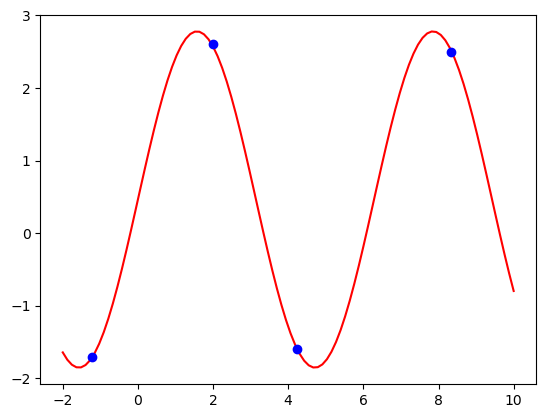

In [44]:
points = [[2, 2.6], [-1.22, -1.7], [8.32, 2.5], [4.23, -1.6]]
x = np.array([p[0] for p in points])
y = np.array([p[1] for p in points])

A = np.vstack([np.ones(x.shape[0]), np.sin(x)]).T
solution = LA.lstsq(A, y.T, rcond=None)
a, b = solution[0]
rss = solution[1][0]

print('a =', a, 'b =', b)
print('rss = ', rss)

t_points = np.linspace(-2, 10, 100)
t_values = a + b * np.sin(t_points)
plt.plot(t_points, t_values, color='red')
plt.plot(x, y, 'o', color='blue')
plt.show()

In [42]:
data = pd.read_csv('LinRegData.csv')
data

,Unnamed: 0,web1,web2,web3
0,0,0.97,1.86,0.41
1,1,1.23,2.18,0.53
2,2,0.80,1.24,0.62
3,3,1.29,0.98,0.51
4,4,1.10,1.23,0.69
5,5,0.67,0.34,0.54
6,6,0.87,0.26,0.62
7,7,1.10,0.16,0.48
8,8,1.92,0.22,0.71
9,9,1.29,0.12,0.62


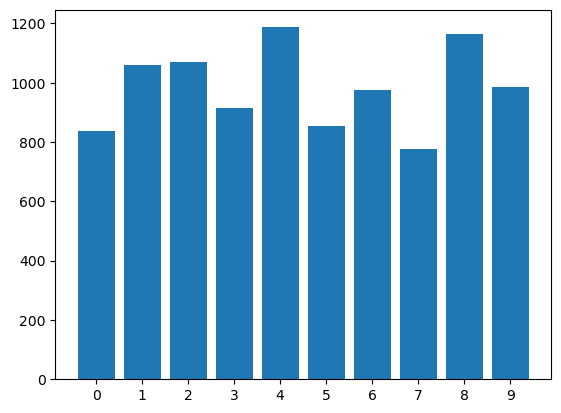

In [47]:
A = data[['web1', 'web2', 'web3']]
b = 1000 * np.ones(A.shape[0])
x, _, _, _ = LA.lstsq(A, b, rcond=None)
result = pd.Series(np.dot(A, x))
plt.xticks(np.linspace(0, 9, 10))
plt.bar(result.index, result.values)
plt.show()